# Final Project

This cumulative project will focus on simulating the olympic sport of curling. Simulation will focus on friction of ice, collision, effects of sweeping, and other physical interactions

## Imports

In [1]:
from vpython import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

## Constants

Values from curling measurements or physics that will not change throughout. Weight and stone come from literature, g is known, and coefficient of friction is an average value estimated for curling. Dt was chosen through experimenting

In [2]:
#Kilograms
stone_weight = 19.96
#Meters
r_stone = 0.145

#m/s^2
g = 9.8

#Ice friction, average of 0.006-0.016 range
ice_mu = 0.011

#Time step
dt = 0.05

## Simple Stone Throw Simulation

### Implementation

Should have spin, poisition and velocity (x and y), radius constant, moving flag

In [3]:
class Stone:
    #Default init with no speed or velocity
    def __init__(self, x=0.0, y=0.0, vx=0.0, vy=0.0, omega=0.0):
        #X and y velocity and position
        self.pos = np.array([x, y], dtype=float)
        self.vel = np.array([vx, vy], dtype=float)
        #Spin
        self.omega = omega
        #Constant radius
        self.radius = r_stone
        self.moving = True
        #Sweeping flag and velocity
        self.sweeping = False
        self.sweep_vel = 0.0  # m/s, typical is 1-3 m/s

    #Get the speed from velocity
    def speed(self):
        return np.linalg.norm(self.vel)


Function that will be used to update a stone's position and velocity and detect if the stone has come to a stop. Run for each stone

In [4]:
#Update stone's velocity and position
def update_stone(stone):
    #If it is stationary, no update
    if not stone.moving:
        return
    speed = stone.speed()
    #Speed small enough to 0, stop
    if speed < 0.01:
        stone.vel = np.array([0.0, 0.0])
        stone.moving = False
        return
    #Magnitude of velocity
    v_hat = stone.vel / speed
    #Force of friction
    a_friction = -ice_mu * g * v_hat
    #New velocity and position
    stone.vel += a_friction * dt
    stone.pos += stone.vel * dt

Used to simulate and store positions and speed for verification

In [5]:
#Simulation to record and update pos/vel
def run_simulation(stone):
    positions = []
    speeds = []
    #Only while the stone is still moving
    while stone.moving:
        positions.append(stone.pos.copy())
        speeds.append(stone.speed())
        update_stone(stone)

    return positions, speeds

### Verification

Launch a stone with a normal throwing speed that should land the stone near the center of the rings. 

In [6]:
#Launch stone straight down the sheet
stone = Stone(x=0, y=0, vx=0, vy=2.46)
positions, speeds = run_simulation(stone)

#Check how far the stone traveled
final_pos = positions[-1]
travel_dist = np.linalg.norm(final_pos)
travel_time = len(positions) * dt

print(f"Final position: y = {final_pos[1]:.2f} m")
print(f"Total distance: {travel_dist:.2f} m")
print(f"Travel time: {travel_time:.1f} s")

Final position: y = 28.01 m
Total distance: 28.01 m
Travel time: 22.8 s


### Visualization

A function that will create an accurately sized ice sheet as well as the rings used for scoring 

In [7]:
#To create the curling sheet
def create_sheet():
    #Dimensions from professional measurements, horizontal
    box(pos=vector(20, 0, -0.05), size=vector(42, 4.75, 0.05), color=color.white, opacity=0.8)
    #Create the rings from official dimensions
    for r, c in zip(
        [1.83, 1.22, 0.61, 0.15],
        [color.blue, color.white, color.red, color.yellow]
    ):
        cylinder(pos=vector(37.97, 0, 0.001), axis=vector(0,0,0.001), radius=r, color=c)

Function to allow the visual objects to be updated from the stone objects

In [8]:
def sync(stone, obj):
    obj.pos.x = stone.pos[0]
    obj.pos.y = stone.pos[1]

Visualize a stone being thrown at the initial velcoity provided and slowing down slowly on the ice, stopping in the center

In [9]:
#Create scene
scene = canvas(title='Curling Sheet', width=900, height=150,
               background=color.black)
#For best viewing
scene.camera.pos = vector(22, 0, 12)
scene.camera.axis = vector(0, 0, -12)
scene.range = 4

create_sheet()

#Stone viusal object
_stone = cylinder(
    pos=vector(0, 0, 0.001),
    axis=vector(0, 0, 0.1),
    radius=0.145,
    color=color.yellow
)

#Stone object for simulation
stone = Stone(x=0, y=0, vx=2.87, vy=0, omega=0.0)

#While stone is moving
while stone.moving:
    #For smoother running
    rate(30)
    #Update the object and its visual
    update_stone(stone)
    sync(stone, _stone)

<IPython.core.display.Javascript object>

The behavior is as expected, and the stone lands in the center of the ring. Visually, the stone seems to be stopping at the right pace.

## Collisions

Now collisions will be implemented. This is a core mechanism of curling, and with the heavy stones, these collisions are treated as elastic in other simulation and literature. 

### Implementation

Function to handle collision physics. Elastic is assumed. CHecks exact distances to determine if collision is neccessary. Velocities of the stones included are adjusted as neccessary

In [10]:
#Pass in two collision stones
def resolve_collision(s1, s2):
    #Calculate exactly if there should be collision
    diff = s1.pos - s2.pos
    dist = np.linalg.norm(diff)

    #Do nothing if far away enough
    if dist > (s1.radius + s2.radius):
        return

    n_hat = diff / dist

    #Separate the two by any overlap
    overlap = (s1.radius + s2.radius) - dist
    s1.pos += (overlap / 2) * n_hat
    s2.pos -= (overlap / 2) * n_hat

    #Relative velocity for the two stones
    rel_vel = s1.vel - s2.vel
    vel_along_n = np.dot(rel_vel, n_hat)

    #If collision already happened don't go again
    if vel_along_n > 0:
        return

    #Add velocity for collision
    s1.vel -= vel_along_n * n_hat
    s2.vel += vel_along_n * n_hat

    s2.moving = True

The same update function as before, but for multiple stones

In [11]:
#Input all stones, update position/velocity
def update_all(stones):
    #Update each
    for i, s1 in enumerate(stones):
        update_stone(s1)
        #For other stones, check for collision. Rough approximation
        for s2 in stones[i+1:]:
            if abs(s1.pos[0] - s2.pos[0]) < (s1.radius + s2.radius) * 2:
                #Elastic collision
                resolve_collision(s1, s2)

#Update all visual objects
def sync_all(stones, objs):
    for stone, obj in zip(stones, objs):
        sync(stone, obj)

To run a simulation of collision for two stones and stil be able to store positions and velocities

In [12]:
#To track and update two stones instead of one
def run_simulation_two(s1, s2):
    #Empty lists
    positions1, positions2 = [], []
    speeds1, speeds2 = [], []
    vels1, vels2 = [], []

    #Go while any stone is moving
    while s1.moving or s2.moving:
        positions1.append(s1.pos.copy())
        positions2.append(s2.pos.copy())
        speeds1.append(s1.speed())
        speeds2.append(s2.speed())
        vels1.append(s1.vel.copy())
        vels2.append(s2.vel.copy())
        #Update both stones
        update_stone(s1)
        update_stone(s2)
        #Check and handle collisions
        if abs(s1.pos[0] - s2.pos[0]) < (s1.radius + s2.radius) * 2:
            resolve_collision(s1, s2)
    #Return metrics for graphing
    return positions1, positions2, speeds1, speeds2, vels1, vels2

### Verification

First, a function will be used to plot the stone paths through collision. Them, three cases will be used of a head on collision (same y value), a glancing collision (from the side), and a miss to examine the behavior.

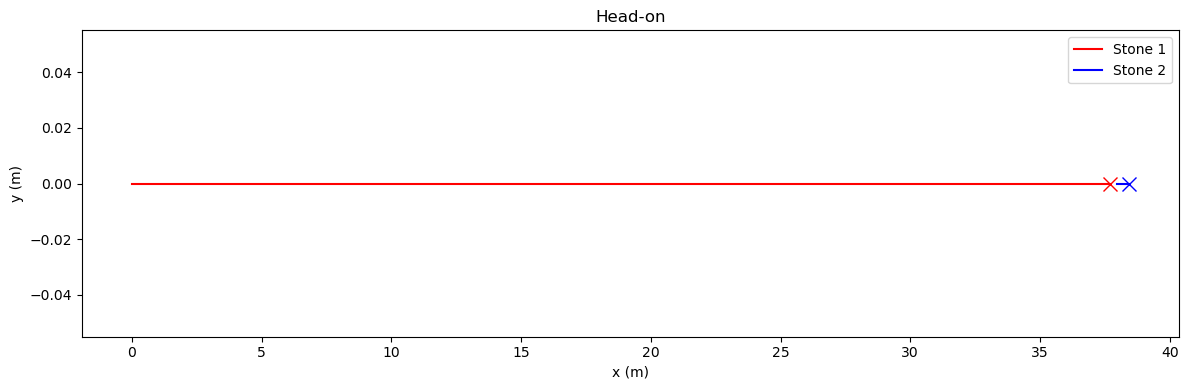

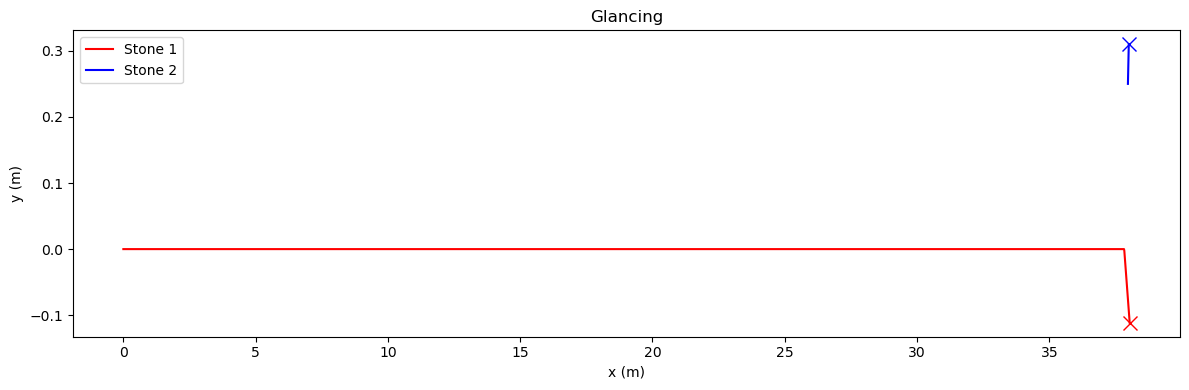

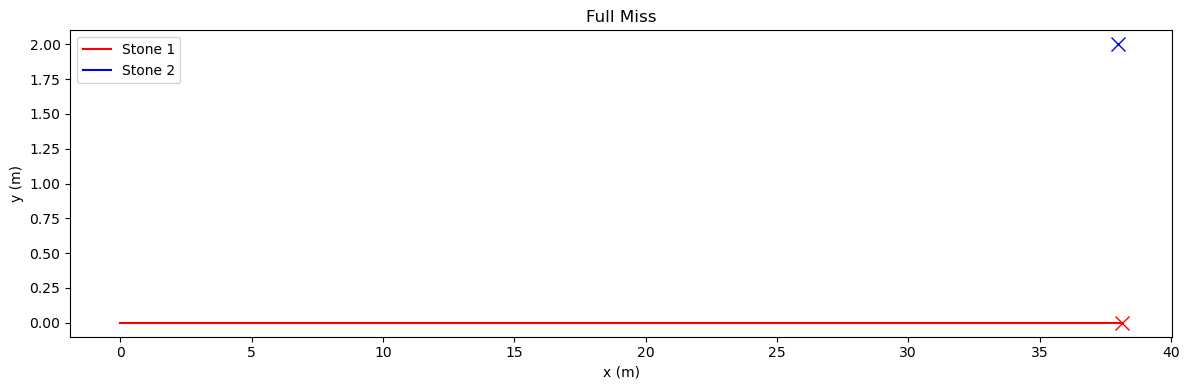

In [13]:
#Plot stones colliding as x's with lines
def plot_paths(stone1, stone2, title="Collision Test"):
    positions1, positions2, speeds1, speeds2, vels1, vels2 = run_simulation_two(stone1, stone2)
    
    positions1 = np.array(positions1)
    positions2 = np.array(positions2)

    fig, ax = plt.subplots(figsize=(12, 4))
    
    #Stone trails
    ax.plot(positions1[:, 0], positions1[:, 1], 'r-', label='Stone 1')
    ax.plot(positions2[:, 0], positions2[:, 1], 'b-', label='Stone 2')
    #Stone objects
    ax.plot(positions1[-1, 0], positions1[-1, 1], 'rx', markersize=10)
    ax.plot(positions2[-1, 0], positions2[-1, 1], 'bx', markersize=10)

    ax.set_title(title)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend()
    plt.tight_layout()
    plt.show()

#Tests
#Straight on collision
plot_paths(Stone(x=0, y=0, vx=2.87, vy=0), Stone(x=37.97, y=0, vx=0, vy=0), "Head-on")
#Launched stone glances the stationary
plot_paths(Stone(x=0, y=0, vx=2.87, vy=0), Stone(x=37.97, y=0.25, vx=0, vy=0), "Glancing")
#Stones miss each other
plot_paths(Stone(x=0, y=0, vx=2.87, vy=0), Stone(x=37.97, y=2.0, vx=0, vy=0), "Full Miss")

The head on stones show a collision and the stationary stone moving only horizontally, which is exactly as expected. The glancing collision shows the moving stone contuin gto move forward but being deflected to the side, and shows the stationary stone being moved to the side.When the stones are not near eachother, there is no collision

This function will be used to verify the conservation of momentum and the speeds of the different stones over time

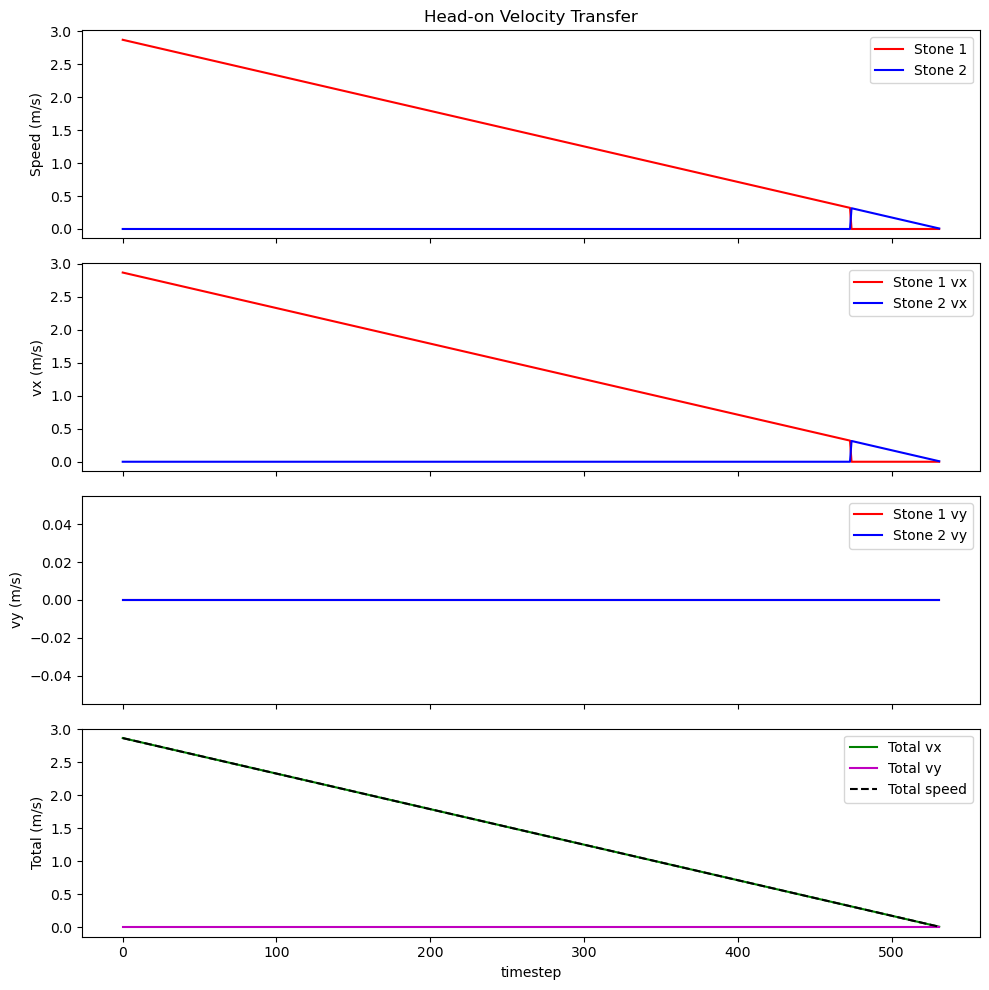

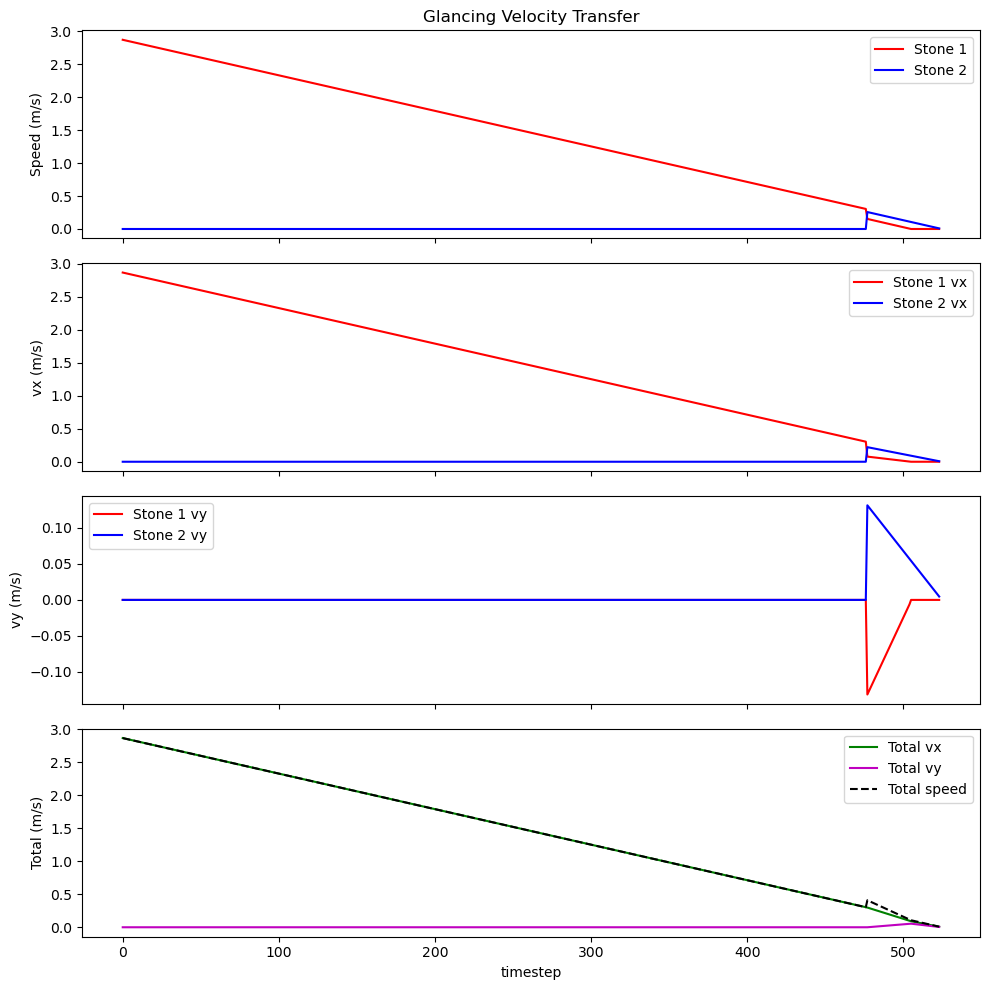

In [14]:
#Velocities of stones and momentum
def plot_velocities(stone1, stone2, title="Velocity Transfer"):
    #Get values to plot first
    positions1, positions2, speeds1, speeds2, vels1, vels2 = run_simulation_two(stone1, stone2)

    vels1 = np.array(vels1)
    vels2 = np.array(vels2)
    speeds1 = np.array(speeds1)
    speeds2 = np.array(speeds2)

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    #Speed
    axes[0].plot(speeds1, 'r-', label='Stone 1')
    axes[0].plot(speeds2, 'b-', label='Stone 2')
    axes[0].set_ylabel('Speed (m/s)')
    axes[0].set_title(title)
    axes[0].legend()

    #Horizontal velocity
    axes[1].plot(vels1[:, 0], 'r-', label='Stone 1 vx')
    axes[1].plot(vels2[:, 0], 'b-', label='Stone 2 vx')
    axes[1].set_ylabel('vx (m/s)')
    axes[1].legend()

    #Vertical velocity
    axes[2].plot(vels1[:, 1], 'r-', label='Stone 1 vy')
    axes[2].plot(vels2[:, 1], 'b-', label='Stone 2 vy')
    axes[2].set_ylabel('vy (m/s)')
    axes[2].legend()

    #Total momentum to see conservation
    total_vx = vels1[:, 0] + vels2[:, 0]
    total_vy = vels1[:, 1] + vels2[:, 1]
    total_speed = speeds1 + speeds2
    axes[3].plot(total_vx, 'g-', label='Total vx')
    axes[3].plot(total_vy, 'm-', label='Total vy')
    axes[3].plot(total_speed, 'k--', label='Total speed')
    axes[3].set_ylabel('Total (m/s)')
    axes[3].set_xlabel('timestep')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

#Head-on collision
plot_velocities(
    Stone(x=0, y=0, vx=2.87, vy=0),
    Stone(x=37.97, y=0, vx=0, vy=0),
    "Head-on Velocity Transfer"
)

#Glancing collision
plot_velocities(
    Stone(x=0, y=0, vx=2.87, vy=0),
    Stone(x=37.97, y=0.145, vx=0, vy=0),
    "Glancing Velocity Transfer"
)

The speeds are shown as constantly decelerating, as expected with friction present. When collisions occur, a transfer of speed is visibly shown, and the x and y values are as expected. Using the total momentum graph helps to see that elasticity is preserved as well.

### Visualization

Visualize a stone moving straight on and hitting another stone, causing a collison

In [15]:
scene = canvas(title='Curling Sheet: Collision', width=900, height=150,
               background=color.black)
scene.camera.pos = vector(22, 0, 12)
scene.camera.axis = vector(0, 0, -12)
scene.range = 4

create_sheet()

#Visual objects
_stone1 = cylinder(pos=vector(0, 0, 0.001), axis=vector(0,0,0.1), radius=0.145, color=color.red)
_stone2 = cylinder(pos=vector(37.97, 0.145, 0.001), axis=vector(0,0,0.1), radius=0.145, color=color.yellow)

#Stones for simulation
stone1 = Stone(x=0, y=0, vx=2.87, vy=0)
stone2 = Stone(x=37.97, y=0, vx=0, vy=0)

stones = [stone1, stone2]
objs = [_stone1, _stone2]

#If either stone is moving
while any(s.moving for s in stones):
    rate(30)
    #Update simulation objects
    update_stone(stone1)
    update_stone(stone2)
    #Detect collision and handle
    if abs(stone1.pos[0] - stone2.pos[0]) < (stone1.radius + stone2.radius) * 2:
        resolve_collision(stone1, stone2)
    #Make sure the visual is the same as the object
    sync(stone1, _stone1)
    sync(stone2, _stone2)

<IPython.core.display.Javascript object>

## Curling

### Implementation

Curling constant is djusted to match real curling expectations. Update function is used now to account for stone spin and the force associated with this spin.

In [16]:
#Curl constant, adjusted to match expected behavior
curl_k = 0.00015

#New update to account for curling
def update_stone(stone):
    if not stone.moving:
        return
    speed = stone.speed()
    if speed < 0.01:
        stone.vel = np.array([0.0, 0.0])
        stone.moving = False
        return

    v_hat = stone.vel / speed

    #Friction deceleration
    a_friction = -ice_mu * g * v_hat

    #Curl force 
    perp = np.array([v_hat[1], -v_hat[0]])
    a_curl = curl_k * stone.omega * speed * perp

    #Adjust the velocity
    stone.vel += (a_friction + a_curl) * dt
    stone.pos += stone.vel * dt

### Verification

Examine a stone thrown with no vertical component but spin, and verify that it travels vertically

In [17]:
#Clockwise spin should have -y curl
stone = Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0)
positions, speeds = run_simulation(stone)
final = positions[-1]
print(f"Final x: {final[0]:.2f} m")
print(f"Final y: {final[1]:.2f} m")

Final x: 38.13 m
Final y: -0.10 m


See how the different values of spin: no spin, clockwise, and counter-clockwise affect the path of the stone

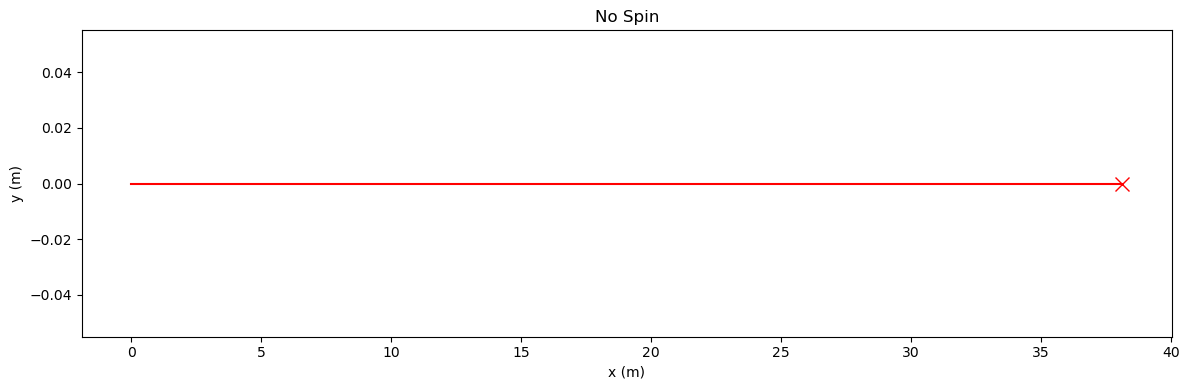

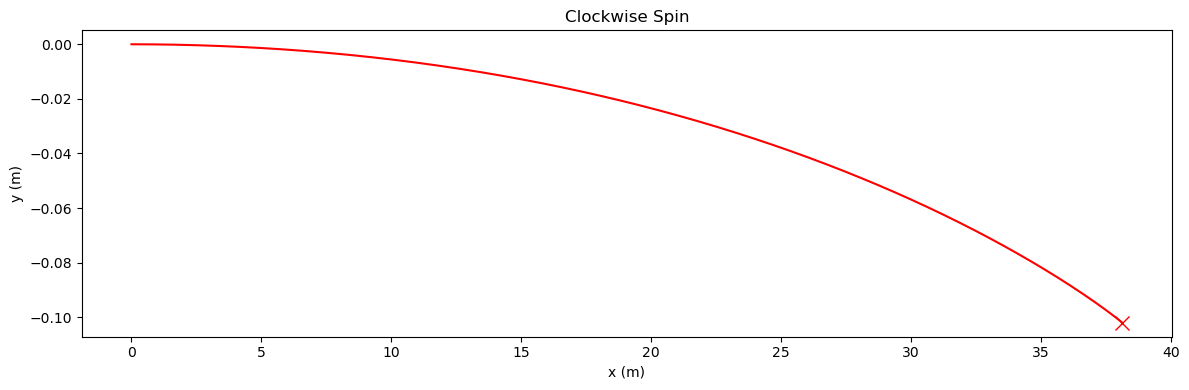

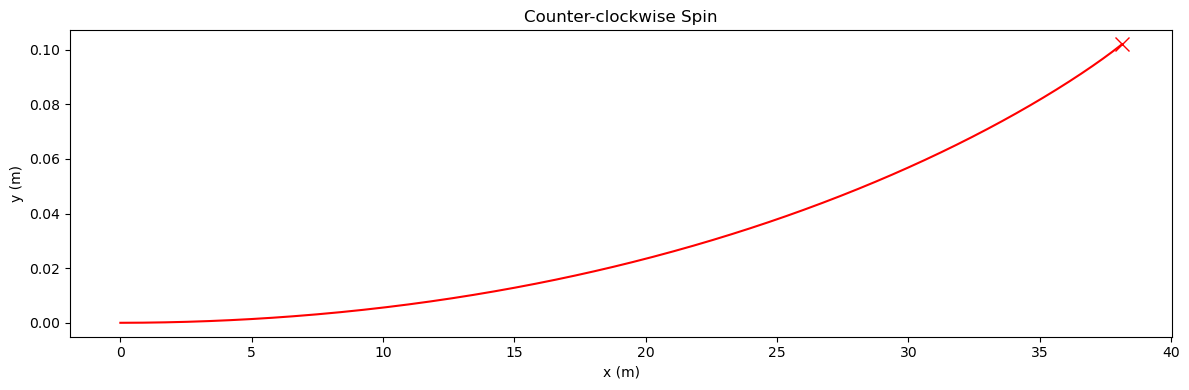

In [18]:
#Plot just one stone with curl
def plot_single(stone, title="Stone Path"):
    positions, speeds = run_simulation(stone)
    positions = np.array(positions)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(positions[:, 0], positions[:, 1], 'r-')
    ax.plot(positions[-1, 0], positions[-1, 1], 'rx', markersize=10)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

#Compare no spin vs spin (clockwise and counter)
plot_single(Stone(x=0, y=0, vx=2.87, vy=0, omega=0.0), "No Spin")
plot_single(Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0), "Clockwise Spin")
plot_single(Stone(x=0, y=0, vx=2.87, vy=0, omega=-2.0), "Counter-clockwise Spin")

This verifies the spin working as wanted. A spin value of 0 is a straight path. A positive spin produces clockwise spin and the expected curved trajectory. A negative value provides the same change but inversed.

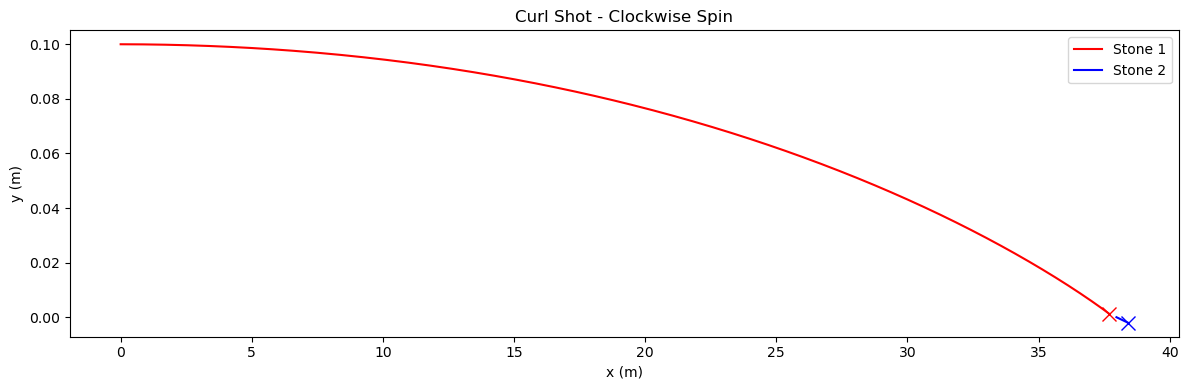

In [19]:
#Clockwise spin for collision
plot_paths(
    Stone(x=0, y=0.1, vx=2.87, vy=0, omega=2.0),
    Stone(x=37.97, y=0, vx=0, vy=0, omega=0.0),
    "Curl Shot - Clockwise Spin"
)

A stone starting at a higher spot on the sheet will colide with a lower stone because of the spin applied. SPin is not transferred as this is the most realistic model possible

### Visualization

Stone will be given spin and will curl into the stationary stone.

In [20]:
scene = canvas(title='Curling Sheet', width=900, height=150,
               background=color.black)
scene.camera.pos = vector(22, 0, 12)
scene.camera.axis = vector(0, 0, -12)
scene.range = 4

create_sheet()

#Simulation stones
stone1 = Stone(x=0, y=0.6, vx=3.3, vy=0, omega=14.0)
stone2 = Stone(x=37.97, y=0, vx=0, vy=0, omega=0.0)

#Visual objects
_stone1 = cylinder(pos=vector(0, 1.5, 0.001), axis=vector(0,0,0.1), radius=0.145, color=color.red)
_stone2 = cylinder(pos=vector(37.97, 0, 0.001), axis=vector(0,0,0.1), radius=0.145, color=color.yellow)

#While any stone is moving
while any(s.moving for s in [stone1, stone2]):
    rate(30)
    update_stone(stone1)
    update_stone(stone2)
    #Detect and resolve collisions
    if abs(stone1.pos[0] - stone2.pos[0]) < (stone1.radius + stone2.radius) * 2:
        resolve_collision(stone1, stone2)
    #Match visual and simulation stones
    sync(stone1, _stone1)
    sync(stone2, _stone2)

<IPython.core.display.Javascript object>

Visually, this simulation aligns with expectations and the graphs provided previously

## Sweeping

### Implementation

Sweeping will reduce the ice coefficient of friction. Create a function that will calculate this new coefficient when sweeping is applied. The rate is chosen as described below

In [21]:
#This value will produce a 15% friction reduction, which is in the middle of an estimated 10-25% reducton
sweep_effect = 0.00125

def effective_mu(stone):
    #Do nothing if not sweeping
    if not stone.sweeping:
        return ice_mu
    #mu decreases with sweep velocity, capped at a minimum
    mu = ice_mu - sweep_effect * stone.sweep_vel
    return max(mu, 0.010)

In [22]:
#Updated update function for new mu calculation
def update_stone(stone):
    if not stone.moving:
        return
    speed = stone.speed()
    if speed < 0.01:
        stone.vel = np.array([0.0, 0.0])
        stone.moving = False
        return

    v_hat = stone.vel / speed
    ########
    #New
    ########
    mu = effective_mu(stone)

    a_friction = -mu * g * v_hat

    perp = np.array([v_hat[1], -v_hat[0]])
    a_curl = curl_k * stone.omega * speed * perp

    stone.vel += (a_friction + a_curl) * dt
    stone.pos += stone.vel * dt

Function to allow us to runa simulation with a specific sweeping velocity. This velocity determines how fastfirction is reduced. A parameter is also used to decide when sweeping starts, as in real curling sweeping can be done at different times and usually is not started until further in the stone's path

### Verification

In [23]:
#Velcoity and starting position for parameters
def run_simulation_sweep(stone, sweep_start_x, sweep_vel=2.0):
    positions, speeds = [], []

    while stone.moving:
        positions.append(stone.pos.copy())
        speeds.append(stone.speed())

        #Turn sweeping on when stone passes sweep_start_x
        if stone.pos[0] > sweep_start_x:
            stone.sweeping = True
            stone.sweep_vel = sweep_vel

        update_stone(stone)

    return positions, speeds

In [24]:
#No sweeping simulation
s1 = Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0)
pos1, _ = run_simulation(s1)

#Sweeping from halfway
s2 = Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0)
pos2, _ = run_simulation_sweep(s2, sweep_start_x=14.0, sweep_vel=2.0)

#Compare the two final positions
pos1, pos2 = np.array(pos1), np.array(pos2)
print(f"No sweep final x: {pos1[-1][0]:.2f}m")
print(f"Swept final x:    {pos2[-1][0]:.2f}m")

No sweep final x: 38.13m
Swept final x:    40.55m


These results verify that friction is properly being reduced and producing more speed and distance for the stone. A distance of around 2.42m is significant and this for a sweep start of 12, meaning late in the stone throw.

### Visualization

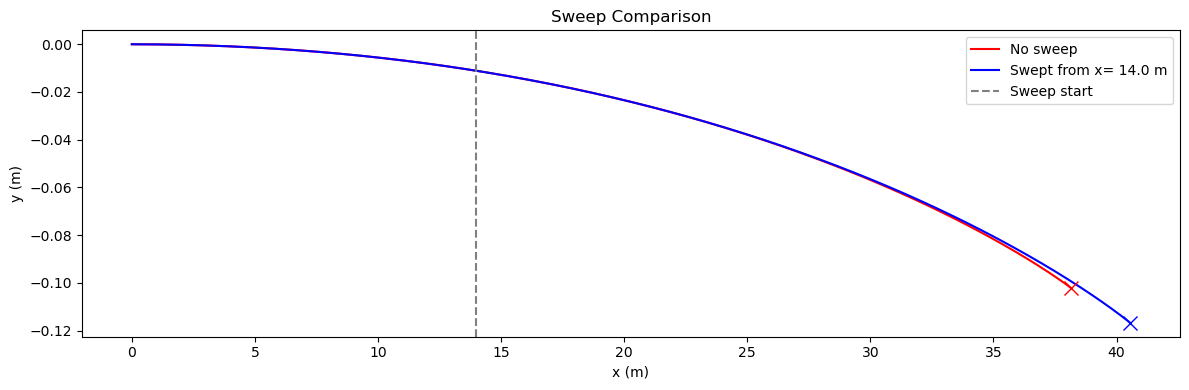

In [25]:
#No sweeping
s1 = Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0)
pos1, _ = run_simulation(s1)

#Sweeping from halfway
s2 = Stone(x=0, y=0, vx=2.87, vy=0, omega=2.0)
pos2, _ = run_simulation_sweep(s2, sweep_start_x=14.0, sweep_vel=2.0)

pos1 = np.array(pos1)
pos2 = np.array(pos2)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pos1[:, 0], pos1[:, 1], 'r-', label='No sweep')
ax.plot(pos2[:, 0], pos2[:, 1], 'b-', label=f'Swept from x= 14.0 m')

#Mark final positions
ax.plot(pos1[-1, 0], pos1[-1, 1], 'rx', markersize=10)
ax.plot(pos2[-1, 0], pos2[-1, 1], 'bx', markersize=10)

#Mark sweep start
ax.axvline(x=14.0, color='gray', linestyle='--', label='Sweep start')

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Sweep Comparison')
ax.legend()
plt.tight_layout()

plt.show()

This helps to visualize a noticeable difference in the trajectories of the two stones for sweeping vs not sweeping. It can be seen that around the start of sweeping is when the two trajectories start to differ and we can see the swept stone travel much further.